# Expolatory Data Analysis on Chezoslovakia Financial Dataset 

In [1]:
!pip install pyodbc sqlalchemy pandas
!pip install seaborn
import matplotlib

# Importing packages

In [2]:
import pyodbc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import numpy as np

# Connecting Python with Databse for fetching data

In [3]:
conn=pyodbc.connect("DRIVER={ODBC driver 17 for SQL Server};"
                    "SERVER=.\SQLEXPRESS;"
                    "DATABASE=Banking_Analysis;"
                    "Trusted_connection=yes;")

# Fetching the required data from Database and storing in Dataframe

In [4]:
client_df=pd.read_sql("Select * from client_360",conn)

In [5]:
dist_df=pd.read_sql("select * from district",conn)

In [6]:
trans_df=pd.read_sql("select * from master_transaction",conn)

In [7]:
loan_df=pd.read_sql("select * from loan",conn)

In [8]:
account_df=pd.read_sql("select * from account",conn)

In [9]:
bins=[18,25,60,120]
labels=['18-25','26-60','60+']
client_df['age_range']=pd.cut(client_df['age'],bins=bins , labels=labels,include_lowest=True)

In [10]:
client_df.columns

Index(['client_id', 'age', 'gender', 'district', 'have_account_flag',
       'total_account', 'owner_account_flag', 'user_account_flag',
       'saving_account_flag', 'salary_account_flag', 'NRI_account_flag',
       'avg_balance', 'card_type', 'active_loan_flag', 'account_opening_date',
       'total_transaction_per_month', 'monthly_fee_flag', 'weekly_fee_flag',
       'transaction_fee_flag', 'last_trans_date', 'age_range'],
      dtype='str')

# Customer Analytics

In [11]:
age_count=client_df.groupby('age_range')['client_id'].count().reset_index(name='count')

In [12]:
age_count

,age_range,count
0,26-60,1625
1,60+,3744


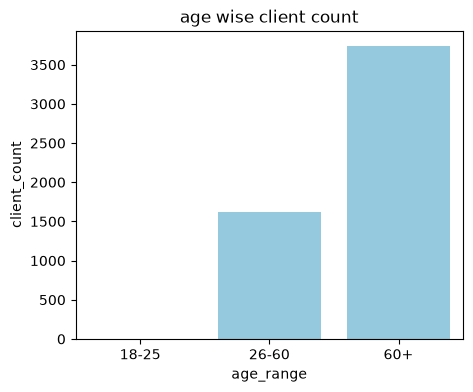

In [13]:
plt.figure(figsize=(5,4))
sns.barplot(data=age_count , x='age_range', y='count' , color='skyblue')
plt.title('age wise client count')
plt.ylabel('client_count')
plt.show()

In [14]:
gender_wise_count=client_df.groupby('gender')['client_id'].count().reset_index(name='count')

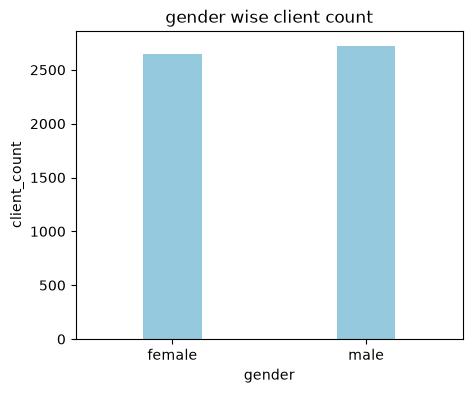

In [15]:
plt.figure(figsize=(5,4))
sns.barplot(data=gender_wise_count , x='gender', y='count' , color='skyblue' , width=0.3)
plt.title('gender wise client count')
plt.ylabel('client_count')
plt.show()

In [16]:
client_df.groupby(['age_range','gender'])['client_id'].count().reset_index(name='count')

,age_range,gender,count
0,26-60,female,829
1,26-60,male,796
2,60+,female,1816
3,60+,male,1928


In [17]:
(client_df['saving_account_flag']==1).sum()

np.int64(1817)

In [18]:
(client_df['salary_account_flag']==1).sum()

np.int64(1720)

In [19]:
(client_df['NRI_account_flag']==1).sum()

np.int64(1832)

In [20]:
client_df.groupby(['saving_account_flag','gender','age_range'])['client_id'].count().reset_index()

,saving_account_flag,gender,age_range,client_id
0,0,female,26-60,545
1,0,female,60+,1211
2,0,male,26-60,509
3,0,male,60+,1287
4,1,female,26-60,284
5,1,female,60+,605
6,1,male,26-60,287
7,1,male,60+,641


In [21]:
client_df.groupby(['salary_account_flag','gender','age_range'])['client_id'].count().reset_index()

,salary_account_flag,gender,age_range,client_id
0,0,female,26-60,554
1,0,female,60+,1239
2,0,male,26-60,537
3,0,male,60+,1319
4,1,female,26-60,275
5,1,female,60+,577
6,1,male,26-60,259
7,1,male,60+,609


In [22]:
client_df.groupby(['NRI_account_flag','gender','age_range'])['client_id'].count().reset_index()

,NRI_account_flag,gender,age_range,client_id
0,0,female,26-60,559
1,0,female,60+,1182
2,0,male,26-60,546
3,0,male,60+,1250
4,1,female,26-60,270
5,1,female,60+,634
6,1,male,26-60,250
7,1,male,60+,678


In [23]:
client_df.groupby(['owner_account_flag','gender','age_range'])['client_id'].count().reset_index()

,owner_account_flag,gender,age_range,client_id
0,0,female,26-60,86
1,0,female,60+,351
2,0,male,26-60,115
3,0,male,60+,317
4,1,female,26-60,743
5,1,female,60+,1465
6,1,male,26-60,681
7,1,male,60+,1611


In [24]:
client_df.groupby(['user_account_flag','gender','age_range'])['client_id'].count().reset_index()

,user_account_flag,gender,age_range,client_id
0,0,female,26-60,743
1,0,female,60+,1465
2,0,male,26-60,681
3,0,male,60+,1611
4,1,female,26-60,86
5,1,female,60+,351
6,1,male,26-60,115
7,1,male,60+,317


In [25]:
client_df.groupby(['active_loan_flag','gender','age_range'])['client_id'].count().reset_index()

,active_loan_flag,gender,age_range,client_id
0,False,female,26-60,735
1,False,female,60+,1640
2,False,male,26-60,706
3,False,male,60+,1750
4,True,female,26-60,94
5,True,female,60+,176
6,True,male,26-60,90
7,True,male,60+,178


In [26]:
client_dist_df=pd.merge(left=client_df,right=dist_df,left_on='district',right_on='district_name',how='left')

In [27]:
client_dist_df.groupby(['region','age_range','gender'])['client_id'].count().reset_index().sort_values(by='client_id',ascending=False)

,region,age_range,gender,client_id
19,north Moravia,60+,male,352
27,south Moravia,60+,male,331
26,south Moravia,60+,female,323
18,north Moravia,60+,female,315
11,east Bohemia,60+,male,239
3,Prague,60+,male,234
2,Prague,60+,female,230
7,central Bohemia,60+,male,226
10,east Bohemia,60+,female,221
6,central Bohemia,60+,female,217


In [28]:
client_df[client_df['have_account_flag']==False]

,client_id,age,gender,district,have_account_flag,total_account,owner_account_flag,user_account_flag,saving_account_flag,salary_account_flag,...,avg_balance,card_type,active_loan_flag,account_opening_date,total_transaction_per_month,monthly_fee_flag,weekly_fee_flag,transaction_fee_flag,last_trans_date,age_range


In [29]:
client_df[client_df['total_account']>1]

,client_id,age,gender,district,have_account_flag,total_account,owner_account_flag,user_account_flag,saving_account_flag,salary_account_flag,...,avg_balance,card_type,active_loan_flag,account_opening_date,total_transaction_per_month,monthly_fee_flag,weekly_fee_flag,transaction_fee_flag,last_trans_date,age_range


In [30]:
def client_segment(avg_balance):
    if avg_balance <= 25000:
        return 'Low'
    elif avg_balance <= 60000:
        return 'Medium'
    elif avg_balance <= 80000:
        return 'High'
    else:
        return 'Premium'

client_df['client_segment'] = client_df['avg_balance'].apply(client_segment)

In [31]:
client_df.head(1)

,client_id,age,gender,district,have_account_flag,total_account,owner_account_flag,user_account_flag,saving_account_flag,salary_account_flag,...,card_type,active_loan_flag,account_opening_date,total_transaction_per_month,monthly_fee_flag,weekly_fee_flag,transaction_fee_flag,last_trans_date,age_range,client_segment
0,1,55,female,Pisek,True,1,1,0,0,0,...,No card,False,2018-03-24,5,1,0,0,2021-12-13,26-60,Low


In [32]:
segment=client_df.groupby(['client_segment'])['client_id'].count().reset_index(name='cnt').sort_values(by='cnt',ascending=False)

In [33]:
segment

,client_segment,cnt
2,Medium,2457
1,Low,1476
0,High,818
3,Premium,618


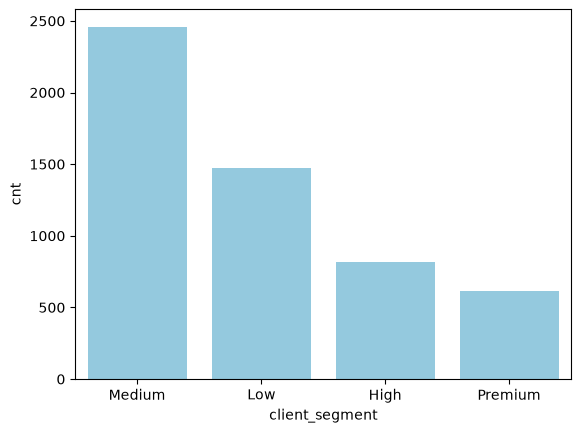

In [34]:
sns.barplot(data=segment,x='client_segment',y='cnt',color='skyblue')
plt.show()

In [35]:
client_df.groupby(['card_type','age_range'])['client_id'].count().reset_index()

,card_type,age_range,client_id
0,No card,26-60,1271
1,No card,60+,3206
2,classic,26-60,185
3,classic,60+,474
4,gold,26-60,24
5,gold,60+,64
6,junior,26-60,145


In [36]:
client_df[client_df['monthly_fee_flag']==True].groupby('age_range')['client_id'].count().reset_index()

,age_range,client_id
0,26-60,1501
1,60+,3479


In [37]:
client_df[client_df['weekly_fee_flag']==True].groupby('age_range')['client_id'].count().reset_index()

,age_range,client_id
0,26-60,92
1,60+,190


In [38]:
client_df[client_df['transaction_fee_flag']==True].groupby('age_range')['client_id'].count().reset_index()

,age_range,client_id
0,26-60,32
1,60+,75


In [39]:
client_df['last_trans_date']=pd.to_datetime(client_df['last_trans_date'])

In [40]:
reference=max(client_df['last_trans_date'])

In [41]:
client_df['day_since_last_trans']=(reference-client_df['last_trans_date']).dt.days

In [42]:
client_df['client_activity_status']=np.where(client_df['day_since_last_trans']<=90,'Active',
                                               np.where(client_df['day_since_last_trans']<=365,'Partially active','Inactive'))

In [43]:
active_status=client_df.groupby('client_activity_status')['client_id'].count().reset_index(name='count')

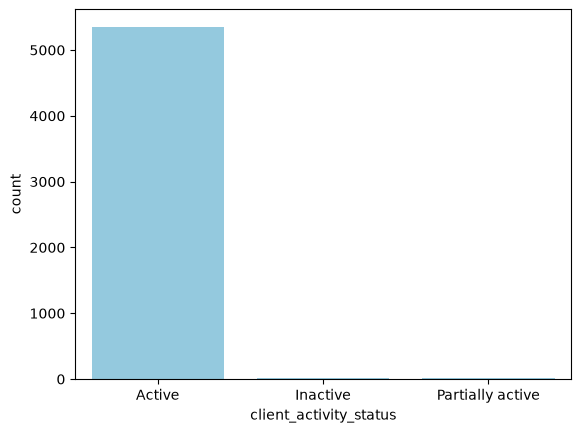

In [44]:
sns.barplot(data=active_status,x='client_activity_status',y='count',color='skyblue')
plt.show()

In [45]:
active_status

,client_activity_status,count
0,Active,5349
1,Inactive,10
2,Partially active,10


# Financial Analysis

In [46]:
year_count=trans_df.groupby('year')['trans_id'].count().reset_index(name='count')

In [47]:
year_count

,year,count
0,2016,28205
1,2017,91628
2,2018,133022
3,2019,196779
4,2020,284409
5,2021,314532


Text(0, 0.5, 'trnasaction_count')

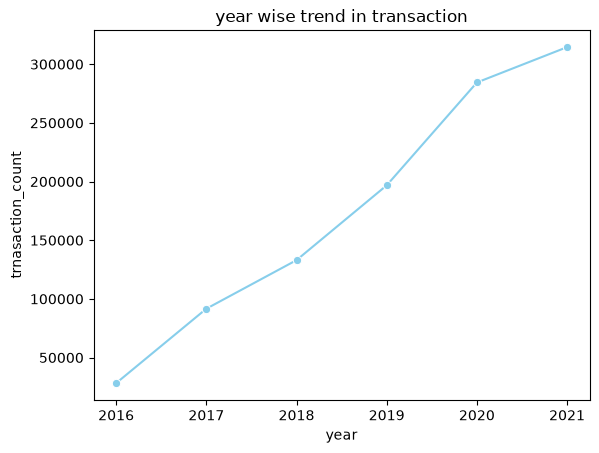

In [48]:
sns.lineplot(data=year_count,x='year',y='count',color='skyblue',marker='o')
plt.show
plt.title('year wise trend in transaction')
plt.ylabel('trnasaction_count')

In [49]:
month_count=trans_df.groupby(['month_no','month'])['trans_id'].count().reset_index(name='count')
month_count = month_count.sort_values('month_no')
month_count

,month_no,month,count
0,1,January,122214
1,2,February,65824
2,3,March,79922
3,4,April,76954
4,5,May,79931
5,6,June,88276
6,7,July,83791
7,8,August,86204
8,9,September,87955
9,10,October,90839


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

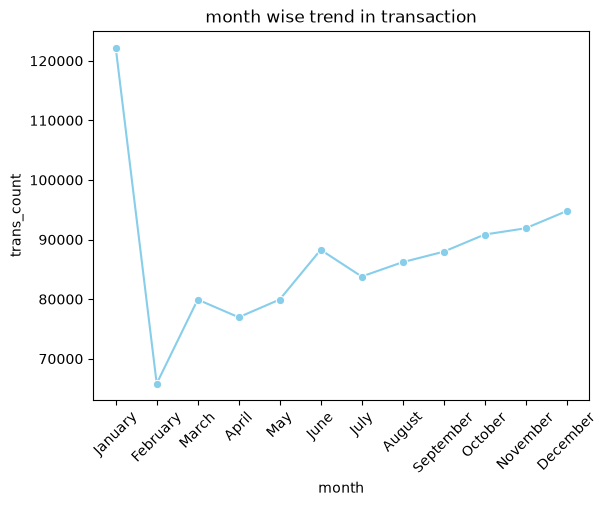

In [50]:
sns.lineplot(data=month_count,x='month',y='count',color='skyblue',marker='o')
plt.show
plt.title('month wise trend in transaction')
plt.ylabel('trans_count')
plt.xticks(rotation=45)


In [51]:
trans_df.groupby(['year'])['trans_id'].count().reset_index(name='cnt')

,year,cnt
0,2016,28205
1,2017,91628
2,2018,133022
3,2019,196779
4,2020,284409
5,2021,314532


In [52]:
type=trans_df.groupby(['year','Type'])['balance'].sum().reset_index(name='total_balance')

In [53]:
type

,year,Type,total_balance
0,2016,Credit,5.362176e+08
1,2016,Withdrawal,4.867063e+08
2,2017,Credit,1.376864e+09
3,2017,Withdrawal,1.901823e+09
4,2018,Credit,1.987278e+09
5,2018,Withdrawal,2.855046e+09
6,2019,Credit,3.058449e+09
7,2019,Withdrawal,4.275542e+09
8,2020,Credit,4.514060e+09
9,2020,Withdrawal,6.538016e+09


In [54]:
trans_df.groupby('operation')['trans_id'].count().reset_index(name='cnt')

,operation,cnt
0,Credit card withdrawal,7706
1,Credit in cash,156320
2,Electronic funds transfer,65226
3,Interest Credit,178663
4,Remittance to Another Bank,208283
5,Withdrawal in cash,432377


In [55]:
trans_df.groupby(['year','Type'])['trans_id'].count().reset_index(name='cnt')

,year,Type,cnt
0,2016,Credit,15212
1,2016,Withdrawal,12993
2,2017,Credit,35743
3,2017,Withdrawal,55885
4,2018,Credit,50633
5,2018,Withdrawal,82389
6,2019,Credit,76964
7,2019,Withdrawal,119815
8,2020,Credit,107678
9,2020,Withdrawal,176731


In [56]:
operation_count=trans_df.groupby(['operation'])['trans_id'].count().reset_index(name='cnt')

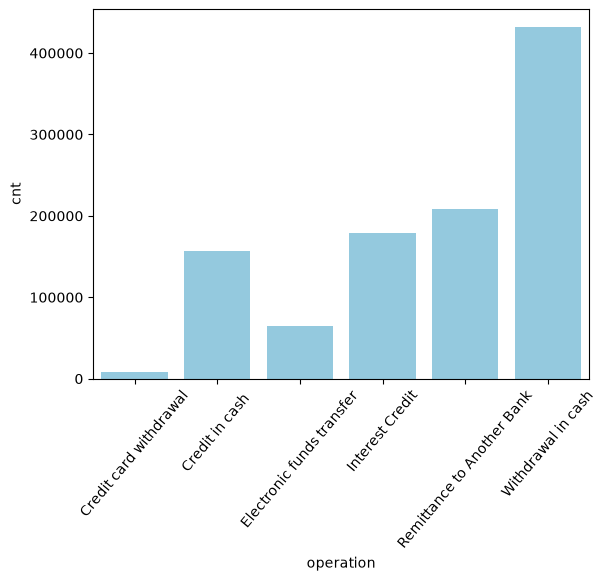

In [57]:
sns.barplot(data=operation_count,x='operation',y='cnt',color='skyblue')
plt.xticks(rotation=50)
plt.show()

In [58]:
trans_df

,trans_id,account_id,Date,Type,operation,amount,balance,Purpose,bank,account_partern_id,year,month,month_no
0,732436,2503,2016-12-31,Withdrawal,Withdrawal in cash,15,27875.500000,Payment on Statement,NaN,Not applicable,2016,December,12
1,730715,2497,2016-12-31,Withdrawal,Withdrawal in cash,15,18709.900391,Payment on Statement,NaN,Not applicable,2016,December,12
2,733937,2508,2016-12-31,Withdrawal,Withdrawal in cash,15,21579.099609,Payment on Statement,NaN,Not applicable,2016,December,12
3,802764,2736,2016-12-31,Withdrawal,Withdrawal in cash,15,32351.400391,Payment on Statement,NaN,Not applicable,2016,December,12
4,801171,2732,2016-12-31,Withdrawal,Withdrawal in cash,15,65012.500000,Payment on Statement,NaN,Not applicable,2016,December,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,490300,1673,2021-01-01,Withdrawal,Withdrawal in cash,400,14183.599609,NaN,NaN,Not applicable,2021,January,1
1048571,490298,1673,2021-01-01,Withdrawal,Withdrawal in cash,1120,14583.599609,NaN,NaN,Not applicable,2021,January,1
1048572,488812,1667,2021-01-01,Withdrawal,Withdrawal in cash,2640,26219.000000,NaN,NaN,Not applicable,2021,January,1
1048573,518574,1771,2021-01-01,Withdrawal,Withdrawal in cash,800,24267.599609,NaN,NaN,Not applicable,2021,January,1


In [59]:
trans_df.groupby('year')['balance'].mean().reset_index(name='avg_balance')

,year,avg_balance
0,2016,36286.766530
1,2017,35790.795390
2,2018,36461.633692
3,2019,37325.009260
4,2020,38965.703395
5,2021,40715.796113


In [60]:
ad_df=pd.merge(left=account_df,right=dist_df,left_on='district_id',right_on='district_id',how='left')

In [61]:
dt_df=pd.merge(left=ad_df,right=trans_df,left_on='account_id',right_on='account_id',how='left')

In [62]:
dt_df

,account_id,district_id,frequency,date,Account_type,final_date,district_name,region,population,municipality_statistics1,...,Type,operation,amount,balance,Purpose,bank,account_partern_id,year,month,month_no
0,1573,63,POPLATEK MESICNE,1997-12-29,Savings account,2020-12-29,Vyskov,south Moravia,86513,38,...,Credit,Credit in cash,1000,1000.000000,cash deposit,NaN,NaN,2020,December,12
1,1573,63,POPLATEK MESICNE,1997-12-29,Savings account,2020-12-29,Vyskov,south Moravia,86513,38,...,Withdrawal,Remittance to Another Bank,3638,16300.900391,Household,PPF Bank,19240260,2021,December,12
2,1573,63,POPLATEK MESICNE,1997-12-29,Savings account,2020-12-29,Vyskov,south Moravia,86513,38,...,Credit,Electronic funds transfer,5492,19938.900391,Old-age Pension,Trinity Bank,56284958,2021,December,12
3,1573,63,POPLATEK MESICNE,1997-12-29,Savings account,2020-12-29,Vyskov,south Moravia,86513,38,...,Credit,Interest Credit,71,17021.500000,Interest Credited,NaN,Not applicable,2021,November,11
4,1573,63,POPLATEK MESICNE,1997-12-29,Savings account,2020-12-29,Vyskov,south Moravia,86513,38,...,Withdrawal,Withdrawal in cash,2560,14461.500000,NaN,NaN,Not applicable,2021,November,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2378,16,POPLATEK MESICNE,1993-01-01,Savings account,2016-01-01,Jindrichuv Hradec,south Bohemia,93931,74,...,Credit,Credit in cash,40196,67459.101562,cash deposit,NaN,NaN,2021,January,1
1048571,2378,16,POPLATEK MESICNE,1993-01-01,Savings account,2016-01-01,Jindrichuv Hradec,south Bohemia,93931,74,...,Withdrawal,Withdrawal in cash,26400,41059.101562,NaN,NaN,Not applicable,2021,January,1
1048572,2378,16,POPLATEK MESICNE,1993-01-01,Savings account,2016-01-01,Jindrichuv Hradec,south Bohemia,93931,74,...,Credit,Credit in cash,11955,27263.099609,cash deposit,NaN,NaN,2021,January,1
1048573,2378,16,POPLATEK MESICNE,1993-01-01,Savings account,2016-01-01,Jindrichuv Hradec,south Bohemia,93931,74,...,Withdrawal,Remittance to Another Bank,9612,15308.099609,Household,Trinity Bank,1222903,2021,January,1


In [63]:
dt_df.groupby('region')['trans_id'].count().reset_index(name='count').sort_values(by='count',ascending=False)

,region,count
4,north Moravia,190265
6,south Moravia,180391
1,central Bohemia,133528
0,Prague,131659
2,east Bohemia,120823
3,north Bohemia,106414
7,west Bohemia,100598
5,south Bohemia,84897


# product perfromance analysis

In [64]:
client_df.groupby('card_type')['client_id'].count().reset_index(name='cnt')

,card_type,cnt
0,No card,4477
1,classic,659
2,gold,88
3,junior,145


In [65]:
client_df.groupby(['client_segment','card_type'])['client_id'].count().reset_index(name='cnt')

,client_segment,card_type,cnt
0,High,No card,561
1,High,classic,203
2,High,gold,21
3,High,junior,33
4,Low,No card,1440
5,Low,classic,20
6,Low,gold,2
7,Low,junior,14
8,Medium,No card,2112
9,Medium,classic,268


In [66]:
client_dist_df.groupby(['region','card_type'])['client_id'].count().reset_index(name='cnt').sort_values(by='cnt',ascending=False)

,region,card_type,cnt
24,south Moravia,No card,807
16,north Moravia,No card,790
8,east Bohemia,No card,563
4,central Bohemia,No card,544
0,Prague,No card,533
12,north Bohemia,No card,451
28,west Bohemia,No card,418
20,south Bohemia,No card,371
25,south Moravia,classic,99
1,Prague,classic,96


In [67]:
client_df.groupby(['saving_account_flag','card_type'])['client_id'].count().reset_index()

,saving_account_flag,card_type,client_id
0,0,No card,2962
1,0,classic,438
2,0,gold,60
3,0,junior,92
4,1,No card,1515
5,1,classic,221
6,1,gold,28
7,1,junior,53


In [68]:
client_df.groupby(['salary_account_flag','card_type'])['client_id'].count().reset_index()

,salary_account_flag,card_type,client_id
0,0,No card,3030
1,0,classic,458
2,0,gold,58
3,0,junior,103
4,1,No card,1447
5,1,classic,201
6,1,gold,30
7,1,junior,42


In [69]:
client_df.groupby(['NRI_account_flag','card_type'])['client_id'].count().reset_index()

,NRI_account_flag,card_type,client_id
0,0,No card,2962
1,0,classic,422
2,0,gold,58
3,0,junior,95
4,1,No card,1515
5,1,classic,237
6,1,gold,30
7,1,junior,50


In [70]:
client_df.groupby(['owner_account_flag','card_type'])['client_id'].count().reset_index()

,owner_account_flag,card_type,client_id
0,0,No card,869
1,1,No card,3608
2,1,classic,659
3,1,gold,88
4,1,junior,145


In [71]:
client_df.groupby(['user_account_flag','card_type'])['client_id'].count().reset_index()

,user_account_flag,card_type,client_id
0,0,No card,3608
1,0,classic,659
2,0,gold,88
3,0,junior,145
4,1,No card,869


In [72]:
client_df.groupby(['card_type'])['avg_balance'].mean().reset_index()

,card_type,avg_balance
0,No card,40693.178803
1,classic,64555.974507
2,gold,82594.886364
3,junior,60434.856552


In [73]:
client_df.groupby(['client_segment','card_type'])['client_id'].count().reset_index()

,client_segment,card_type,client_id
0,High,No card,561
1,High,classic,203
2,High,gold,21
3,High,junior,33
4,Low,No card,1440
5,Low,classic,20
6,Low,gold,2
7,Low,junior,14
8,Medium,No card,2112
9,Medium,classic,268


# Area wise analysis

In [74]:
cust_dist_df=pd.merge(left=client_df,right=dist_df,left_on='district',right_on='district_name',how='inner')

In [75]:
cust_dist_df.groupby('district')['client_id'].count().reset_index(name='cnt')

,district,cnt
0,Benesov,46
1,Beroun,63
2,Blansko,57
3,Breclav,54
4,Brno - mesto,155
...,...,...
72,Vsetin,50
73,Vyskov,56
74,Zdar nad Sazavou,66
75,Zlin,109


In [76]:
cust_dist_df.groupby('region')['client_id'].count().reset_index(name='cnt')

,region,cnt
0,Prague,663
1,central Bohemia,664
2,east Bohemia,660
3,north Bohemia,561
4,north Moravia,920
5,south Bohemia,449
6,south Moravia,937
7,west Bohemia,515


In [77]:
pd.set_option('display.max_rows', None)

In [78]:
cust_dist_df.groupby(['district_name','population','number_of_cities'])['client_id'].count().reset_index(name='cnt').sort_values(by='cnt',ascending=False)

,district_name,population,number_of_cities,cnt
17,Hl.m. Praha,1204953,1,663
43,Ostrava - mesto,323870,1,180
26,Karvina,285387,7,169
4,Brno - mesto,387570,1,155
75,Zlin,197099,10,109
41,Olomouc,226122,4,104
15,Frydek - Mistek,228848,6,86
38,Nachod,112709,10,76
71,Usti nad Orlici,139012,10,73
29,Kolin,95616,6,71


In [79]:
cust_dist_df.groupby(['district_name','age_range'])['client_id'].count().reset_index()

,district_name,age_range,client_id
0,Benesov,26-60,21
1,Benesov,60+,25
2,Beroun,26-60,18
3,Beroun,60+,45
4,Blansko,26-60,20
5,Blansko,60+,37
6,Breclav,26-60,19
7,Breclav,60+,35
8,Brno - mesto,26-60,50
9,Brno - mesto,60+,105


In [80]:
cust_dist_df.groupby(['district_name','card_type'])['client_id'].count().reset_index()

,district_name,card_type,client_id
0,Benesov,No card,34
1,Benesov,classic,8
2,Benesov,junior,4
3,Beroun,No card,56
4,Beroun,classic,4
5,Beroun,gold,1
6,Beroun,junior,2
7,Blansko,No card,45
8,Blansko,classic,10
9,Blansko,junior,2


In [81]:
cust_dist_df.groupby(['district_name','active_loan_flag'])['client_id'].count().reset_index(name='cnt')

,district_name,active_loan_flag,cnt
0,Benesov,False,38
1,Benesov,True,8
2,Beroun,False,58
3,Beroun,True,5
4,Blansko,False,52
5,Blansko,True,5
6,Breclav,False,50
7,Breclav,True,4
8,Brno - mesto,False,134
9,Brno - mesto,True,21


In [82]:
cust_dist_df.groupby(['district_name','client_segment'])['client_id'].count().reset_index(name='cnt')

,district_name,client_segment,cnt
0,Benesov,High,8
1,Benesov,Low,10
2,Benesov,Medium,21
3,Benesov,Premium,7
4,Beroun,High,10
5,Beroun,Low,21
6,Beroun,Medium,29
7,Beroun,Premium,3
8,Blansko,High,15
9,Blansko,Low,10


In [83]:
cust_dist_df.groupby(['district_name','client_activity_status'])['client_id'].count().reset_index(name='cnt')

,district_name,client_activity_status,cnt
0,Benesov,Active,46
1,Beroun,Active,63
2,Blansko,Active,57
3,Breclav,Active,52
4,Breclav,Inactive,2
5,Brno - mesto,Active,155
6,Brno - venkov,Active,63
7,Bruntal,Active,45
8,Ceska Lipa,Active,55
9,Ceske Budejovice,Active,45


In [84]:
cust_dist_df.groupby('district_name')['avg_balance'].mean().reset_index(name='avg_balance').sort_values(by='avg_balance',ascending=False)

,district_name,avg_balance
71,Usti nad Orlici,56815.401370
47,Plzen - jih,53030.454545
73,Vyskov,51509.883929
2,Blansko,51290.357895
19,Hradec Kralove,50852.921818
40,Nymburk,49975.560000
72,Vsetin,49705.010000
70,Usti nad Labem,49322.320000
74,Zdar nad Sazavou,49238.403030
58,Rychnov nad Kneznou,48630.276667


In [85]:
dist_df[['district_name','average_salary']].sort_values(by='average_salary',ascending=False)

,district_name,average_salary
0,Hl.m. Praha,12541
7,Mlada Boleslav,11277
25,Plzen - mesto,10787
73,Ostrava - mesto,10673
38,Most,10446
69,Karvina,10177
9,Praha - vychod,10124
13,Ceske Budejovice,10045
6,Melnik,9920
53,Brno - mesto,9897


# Loan Portfolio Analysis

In [86]:
total_loans = loan_df.shape[0]
print("Total Loans:", total_loans)

Total Loans: 682


In [87]:
loan_df.groupby('status')['loan_id'].count().reset_index(name='cnt')

,status,cnt
0,A,203
1,B,31
2,C,403
3,D,45


In [88]:
safe_loans = loan_df[loan_df['status'] == 'A'].shape[0]

In [89]:
print('safe_loans:',safe_loans)

safe_loans: 203


In [90]:
risky_loans = loan_df[loan_df['status'].isin(['B','D'])].shape[0]

In [91]:
print('risky_loans:',risky_loans)

risky_loans: 76


In [92]:
active_loans = loan_df[loan_df['status'].isin(['C','D'])].shape[0]

In [93]:
print('active_loans:',active_loans)

active_loans: 448


In [94]:
safe_rate = safe_loans / total_loans
print("Safe Loan %:", safe_rate)


Safe Loan %: 0.29765395894428154


In [95]:
risk_rate = risky_loans / total_loans
print("Risky Loan %:", risk_rate)

Risky Loan %: 0.11143695014662756


In [96]:
loan_df.groupby('status')['amount'].mean().reset_index()

,status,amount
0,A,91641.458128
1,B,140720.903226
2,C,171410.352357
3,D,249284.533333


In [97]:
loan_df.groupby('status')['payments'].mean().reset_index()

,status,payments
0,A,4264.137931
1,B,5396.258065
2,C,3938.535980
3,D,5286.644444
